In [38]:
import pandas as pd
import numpy as np
import subprocess
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score


In [16]:
expr = pd.read_csv("cluster5_expression_variance.csv")
meta = pd.read_csv("wk0_metadata_from_series_matrix.csv")

# Clean metadata
meta = meta.replace([".", "NA", "N/A", ""], np.nan)
print(meta.head)

<bound method NDFrame.head of       sample_id                       sample_title  \
0    GSM3068409  CNTO1275CRD3002-20149 I-WK0 ileum   
1    GSM3068410  CNTO1275CRD3002-20963 I-WK0 ileum   
2    GSM3068411  CNTO1275CRD3002-20577 I-WK0 ileum   
3    GSM3068412  CNTO1275CRD3002-20631 I-WK0 ileum   
4    GSM3068413  CNTO1275CRD3002-20367 I-WK0 ileum   
..          ...                                ...   
136  GSM3068545  CNTO1275CRD3002-20350 I-WK0 ileum   
137  GSM3068546  CNTO1275CRD3002-20928 I-WK0 ileum   
138  GSM3068547  CNTO1275CRD3002-20929 I-WK0 ileum   
139  GSM3068548  CNTO1275CRD3002-21010 I-WK0 ileum   
140  GSM3068549  CNTO1275CRD3002-20170 I-WK0 ileum   

                                              cel_file tissue  \
0    ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3068...  ileum   
1    ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3068...  ileum   
2    ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3068...  ileum   
3    ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3068...  ileum

In [17]:
for col in ["sample_id", "visit", "treatment_induction", "i_wk8_response", "gi_involvement"]:
    if col in meta.columns:
        meta[col] = meta[col].astype(str).str.strip()

meta["ileum_ses_cd_score"] = pd.to_numeric(meta["ileum_ses_cd_score"], errors="coerce")

# Keep eligible samples
meta_sub = meta[
    (meta["visit"] == "I-WK0") &
    (meta["treatment_induction"] == "Ust") &
    (meta["i_wk8_response"].isin(["Y", "N"])) &
    (meta["ileum_ses_cd_score"].notna())
].copy()
print(meta_sub.head())

     sample_id                       sample_title  \
55  GSM3068464  CNTO1275CRD3002-20142 I-WK0 ileum   
56  GSM3068465  CNTO1275CRD3002-20986 I-WK0 ileum   
57  GSM3068466  CNTO1275CRD3002-20554 I-WK0 ileum   
58  GSM3068467  CNTO1275CRD3002-20109 I-WK0 ileum   
59  GSM3068468  CNTO1275CRD3002-20171 I-WK0 ileum   

                                             cel_file tissue  \
55  ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3068...  ileum   
56  ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3068...  ileum   
57  ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3068...  ileum   
58  ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3068...  ileum   
59  ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM3068...  ileum   

               diagnosis                subject treatment_induction  \
55  Crohn's disease (CD)  CNTO1275CRD3002-20142                 Ust   
56  Crohn's disease (CD)  CNTO1275CRD3002-20986                 Ust   
57  Crohn's disease (CD)  CNTO1275CRD3002-20554                 Ust   
58  Crohn's 

In [18]:
m1 = meta["visit"] == "I-WK0"
m2 = meta["treatment_induction"] == "Ust"
m3 = meta["i_wk8_response"].isin(["Y", "N"])
m4 = meta["ileum_ses_cd_score"].notna()

print("visit == I-WK0:", m1.sum())
print("treatment_induction == UST:", m2.sum())
print("response in Y/N:", m3.sum())
print("ses_cd notna:", m4.sum())

print("visit + treatment:", (m1 & m2).sum())
print("visit + treatment + response:", (m1 & m2 & m3).sum())
print("all four:", (m1 & m2 & m3 & m4).sum())

visit == I-WK0: 141
treatment_induction == UST: 86
response in Y/N: 141
ses_cd notna: 101
visit + treatment: 86
visit + treatment + response: 86
all four: 59


In [19]:
sample_ids = meta_sub["sample_id"].tolist()

# Keep only samples present in expression matrix
sample_ids = [s for s in sample_ids if s in expr.columns]

meta_sub = meta_sub.set_index("sample_id").loc[sample_ids].copy()
expr_sub = expr[["gene_symbol"] + sample_ids].copy()

# Response
y = meta_sub["i_wk8_response"].map({"Y": 1, "N": 0}).astype(int)

print(expr_sub.head())
print(expr.shape)

  gene_symbol  GSM3068464  GSM3068465  GSM3068466  GSM3068467  GSM3068468  \
0       ABCB1      9.0610      8.0257      8.5637      6.8814      5.7214   
1       ABCG2     10.4301      9.5001      9.4714      8.3559      7.8790   
2         ACE      8.5794      8.0195      8.4307      6.4272      5.2649   
3        ACE2     11.1851     10.0157     10.5721      9.8970      8.3597   
4       ADCY9      6.1476      6.2149      6.0393      5.4644      5.4098   

   GSM3068469  GSM3068470  GSM3068471  GSM3068473  ...  GSM3068536  \
0      6.4253      8.6957      5.8390      5.6381  ...      6.6797   
1      8.0749     10.0072      7.9217      7.2037  ...      8.7102   
2      5.6755      9.6649      6.7951      4.8345  ...      5.2633   
3      9.3895     10.6118      9.7625      9.0124  ...      9.3198   
4      5.4046      6.4313      4.9539      5.4080  ...      5.4142   

   GSM3068537  GSM3068538  GSM3068539  GSM3068540  GSM3068542  GSM3068544  \
0      7.7496      8.8583      6.6153  

In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

expr_indexed = expr_sub.set_index("gene_symbol")

model_names   = ["LASSO", "Ridge", "Elastic Net", "Random Forest", "XGBoost"]
feature_keys  = ["gene_only", "sescd_only", "gene_and_sescd"]
feature_labels = {
    "gene_only":      "Top-5 Cluster5 genes only",
    "sescd_only":     "SES-CD only",
    "gene_and_sescd": "Top-5 Cluster5 genes + SES-CD",
}

results = {
    model: {feat: [] for feat in feature_keys}
    for model in model_names
}

for fold, (train_idx, test_idx) in enumerate(cv.split(meta_sub.index, y), start=1):
    train_ids = meta_sub.index[train_idx].tolist()
    test_ids  = meta_sub.index[test_idx].tolist()

    print(f"\n{'='*40}")
    print(f"=== Fold {fold} ===")
    print(f"{'='*40}")

    y_train = meta_sub.loc[train_ids, "i_wk8_response"].map({"Y": 1, "N": 0}).astype(int)
    y_test  = meta_sub.loc[test_ids,  "i_wk8_response"].map({"Y": 1, "N": 0}).astype(int)
    print("Train class counts:\n", y_train.value_counts())
    print("Test class counts:\n",  y_test.value_counts())

    # ── nested limma on cluster5 genes (training fold only) ──────────────
    expr_train = expr_sub[["gene_symbol"] + train_ids].copy()
    meta_train = meta_sub.loc[train_ids].copy()
    meta_train = meta_train.reset_index()[["sample_id", "ileum_ses_cd_score", "gi_involvement"]].copy()
    meta_train["response"] = y_train.values
    meta_train = meta_train.rename(columns={"ileum_ses_cd_score": "ses_cd"})

    expr_file = f"expr_cl5_train_fold{fold}.csv"
    meta_file = f"meta_cl5_train_fold{fold}.csv"
    out_file  = f"limma_cl5_out_fold{fold}.csv"

    expr_train.to_csv(expr_file, index=False)
    meta_train.to_csv(meta_file, index=False)

    subprocess.run(
        ["Rscript", "run_limma_fold.R", expr_file, meta_file, out_file],
        check=True
    )

    limma_res = pd.read_csv(out_file)
    top_n = 5
    top_features = limma_res["Gene_symbol"].dropna().head(top_n).tolist()
    available_features = [g for g in top_features if g in expr_indexed.index]
    if not available_features:
        raise ValueError(f"No limma genes found in cluster5 expression matrix for fold {fold}.")
    print(f"\nTop {top_n} DGE genes from Cluster5 (fold {fold}):", available_features)

    # ── build three feature matrices ──────────────────────────────────────
    X_gene      = expr_indexed[train_ids].loc[available_features].T.copy()
    X_gene_test = expr_indexed[test_ids].loc[available_features].T.copy()

    X_sescd      = meta_sub.loc[train_ids, ["ileum_ses_cd_score"]].copy()
    X_sescd_test = meta_sub.loc[test_ids,  ["ileum_ses_cd_score"]].copy()

    X_combined      = X_gene.copy()
    X_combined["ses_cd"] = meta_sub.loc[train_ids, "ileum_ses_cd_score"].values
    X_combined_test = X_gene_test.copy()
    X_combined_test["ses_cd"] = meta_sub.loc[test_ids, "ileum_ses_cd_score"].values

    feature_sets = {
        "gene_only":      (X_gene,     X_gene_test),
        "sescd_only":     (X_sescd,    X_sescd_test),
        "gene_and_sescd": (X_combined, X_combined_test),
    }

    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    spw = neg / pos

    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    for feat_key, (X_tr, X_te) in feature_sets.items():
        print(f"\n  >> {feature_labels[feat_key]}")

        # ── LASSO ────────────────────────────────────────────────────────
        lasso = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegressionCV(
                penalty="l1", solver="saga",
                Cs=10, cv=5, scoring="roc_auc",
                class_weight="balanced",
                max_iter=5000, n_jobs=-1, random_state=42
            ))
        ])
        lasso.fit(X_tr, y_train)
        auc = roc_auc_score(y_test, lasso.predict_proba(X_te)[:, 1])
        results["LASSO"][feat_key].append(auc)
        clf = lasso.named_steps["clf"]
        print(f"     LASSO        | C={clf.C_[0]:.4f}  nonzero={(clf.coef_.ravel() != 0).sum()}  AUC={auc:.3f}")

        # ── Ridge ────────────────────────────────────────────────────────
        ridge = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegressionCV(
                penalty="l2", solver="saga",
                Cs=10, cv=5, scoring="roc_auc",
                class_weight="balanced",
                max_iter=5000, n_jobs=-1, random_state=42
            ))
        ])
        ridge.fit(X_tr, y_train)
        auc = roc_auc_score(y_test, ridge.predict_proba(X_te)[:, 1])
        results["Ridge"][feat_key].append(auc)
        clf = ridge.named_steps["clf"]
        print(f"     Ridge        | C={clf.C_[0]:.4f}  AUC={auc:.3f}")

        # ── Elastic Net ──────────────────────────────────────────────────
        enet = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegressionCV(
                penalty="elasticnet", solver="saga",
                l1_ratios=[0.1, 0.3, 0.5, 0.7, 0.9],
                Cs=10, cv=5, scoring="roc_auc",
                class_weight="balanced",
                max_iter=5000, n_jobs=-1, random_state=42
            ))
        ])
        enet.fit(X_tr, y_train)
        auc = roc_auc_score(y_test, enet.predict_proba(X_te)[:, 1])
        results["Elastic Net"][feat_key].append(auc)
        clf = enet.named_steps["clf"]
        print(f"     Elastic Net  | C={clf.C_[0]:.4f}  l1_ratio={clf.l1_ratio_[0]}  nonzero={(clf.coef_.ravel() != 0).sum()}  AUC={auc:.3f}")

        # ── Random Forest ────────────────────────────────────────────────
        rf_pipeline = Pipeline([
            ("clf", RandomForestClassifier(
                class_weight="balanced",
                random_state=42, n_jobs=-1
            ))
        ])
        rf_grid = GridSearchCV(
            estimator=rf_pipeline,
            param_grid={
                "clf__n_estimators":   [100, 200],
                "clf__max_depth":      [2, 3, 5],
                "clf__min_samples_split": [5, 10],
                "clf__min_samples_leaf":  [2, 4],
                "clf__max_features":   ["sqrt", 0.2],
            },
            scoring="roc_auc", cv=inner_cv, n_jobs=-1, verbose=0
        )
        rf_grid.fit(X_tr, y_train)
        auc = roc_auc_score(y_test, rf_grid.best_estimator_.predict_proba(X_te)[:, 1])
        results["Random Forest"][feat_key].append(auc)
        print(f"     Random Forest| best={rf_grid.best_params_}  AUC={auc:.3f}")

        # ── XGBoost ──────────────────────────────────────────────────────
        xgb_pipeline = Pipeline([
            ("clf", XGBClassifier(
                scale_pos_weight=spw,
                random_state=42, n_jobs=-1,
                eval_metric="logloss", verbosity=0
            ))
        ])
        xgb_grid = GridSearchCV(
            estimator=xgb_pipeline,
            param_grid={
                "clf__n_estimators":     [100, 200],
                "clf__max_depth":        [2, 3, 5],
                "clf__learning_rate":    [0.01, 0.1, 0.3],
                "clf__subsample":        [0.6, 0.8, 1.0],
                "clf__colsample_bytree": [0.6, 0.8, 1.0],
            },
            scoring="roc_auc", cv=inner_cv, n_jobs=-1, verbose=0
        )
        xgb_grid.fit(X_tr.values, y_train)
        auc = roc_auc_score(y_test, xgb_grid.best_estimator_.predict_proba(X_te.values)[:, 1])
        results["XGBoost"][feat_key].append(auc)
        print(f"     XGBoost      | best={xgb_grid.best_params_}  AUC={auc:.3f}")

# ── Final summary table ───────────────────────────────────────────────────
print("\n" + "="*60)
print("FINAL COMPARISON SUMMARY")
print("="*60)
summary_rows = []
for model in model_names:
    for feat_key in feature_keys:
        aucs = results[model][feat_key]
        summary_rows.append({
            "Model":       model,
            "Features":    feature_labels[feat_key],
            "Mean AUC":    round(np.mean(aucs), 3),
            "Std AUC":     round(np.std(aucs),  3),
            "Fold AUCs":   [round(a, 3) for a in aucs],
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)



=== Fold 1 ===
Train class counts:
 i_wk8_response
1    26
0    21
Name: count, dtype: int64
Test class counts:
 i_wk8_response
0    6
1    6
Name: count, dtype: int64
[1] "(Intercept)" "response1"  
  (Intercept) response1
1           1         0
2           1         0
3           1         0
4           1         0
5           1         0
6           1         0

Top 5 DGE genes from Cluster5 (fold 1): ['ADCY9', 'CDHR1', 'GDPD2', 'PAPSS2', 'VDR']

  >> Top-5 Cluster5 genes only
     LASSO        | C=2.7826  nonzero=2  AUC=0.361
     Ridge        | C=0.0464  AUC=0.306
     Elastic Net  | C=0.0464  l1_ratio=0.1  nonzero=5  AUC=0.306
     Random Forest| best={'clf__max_depth': 3, 'clf__max_features': 0.2, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}  AUC=0.306
     XGBoost      | best={'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.3, 'clf__max_depth': 2, 'clf__n_estimators': 100, 'clf__subsample': 0.6}  AUC=0.222

  >> SES-CD only
     LA

,Model,Features,Mean AUC,Std AUC,Fold AUCs
0,LASSO,Top-5 Cluster5 genes only,0.492,0.155,"[0.361, 0.583, 0.257, 0.657, 0.6]"
1,LASSO,SES-CD only,0.455,0.094,"[0.472, 0.5, 0.271, 0.5, 0.533]"
2,LASSO,Top-5 Cluster5 genes + SES-CD,0.480,0.144,"[0.361, 0.583, 0.257, 0.6, 0.6]"
3,Ridge,Top-5 Cluster5 genes only,0.483,0.130,"[0.306, 0.583, 0.371, 0.657, 0.5]"
4,Ridge,SES-CD only,0.540,0.165,"[0.472, 0.722, 0.271, 0.7, 0.533]"
5,Ridge,Top-5 Cluster5 genes + SES-CD,0.501,0.078,"[0.417, 0.583, 0.4, 0.571, 0.533]"
6,Elastic Net,Top-5 Cluster5 genes only,0.503,0.130,"[0.306, 0.583, 0.4, 0.657, 0.567]"
7,Elastic Net,SES-CD only,0.455,0.094,"[0.472, 0.5, 0.271, 0.5, 0.533]"
8,Elastic Net,Top-5 Cluster5 genes + SES-CD,0.492,0.118,"[0.306, 0.583, 0.4, 0.571, 0.6]"
9,Random Forest,Top-5 Cluster5 genes only,0.451,0.100,"[0.306, 0.528, 0.486, 0.571, 0.367]"


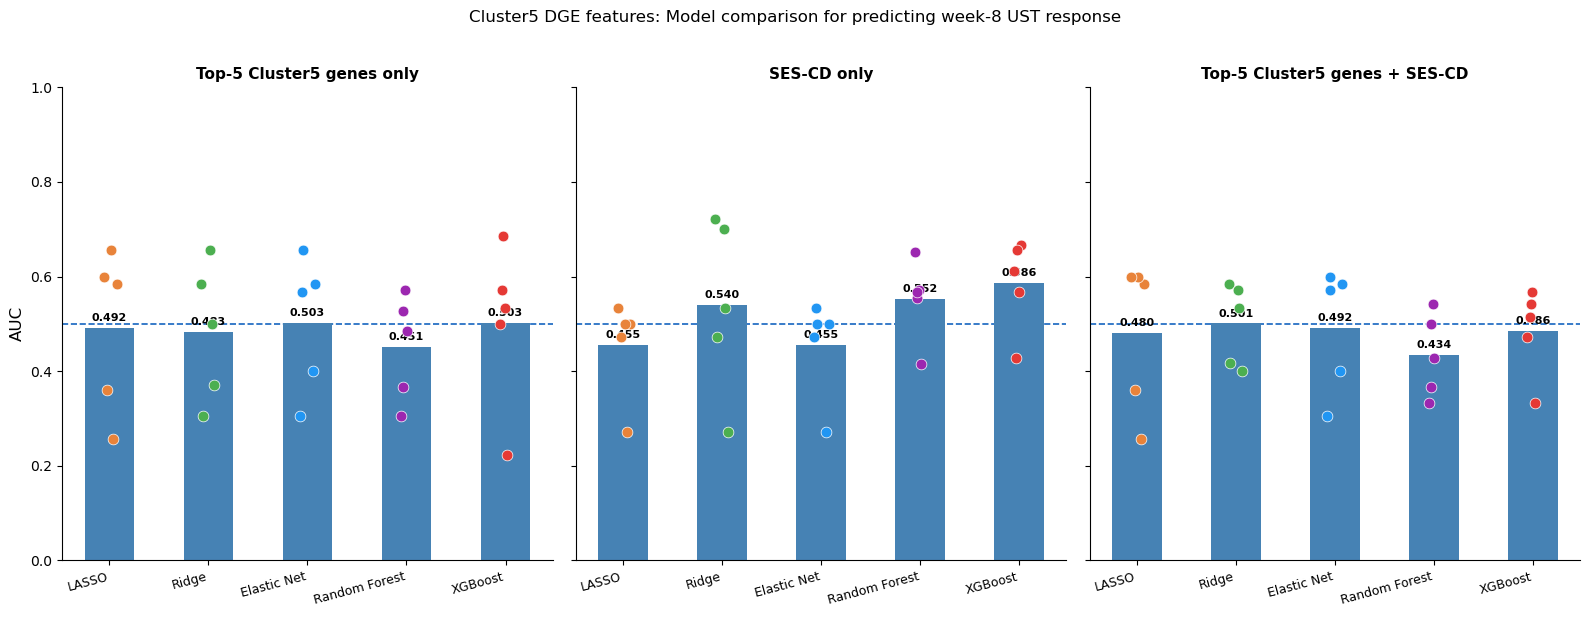

Saved: cl5_limma_model_comparison.png


In [42]:
import matplotlib.pyplot as plt
import numpy as np

feature_keys_plot   = ["gene_only", "sescd_only", "gene_and_sescd"]
feature_labels_plot = ["Top-5 Cluster5 genes only", "SES-CD only", "Top-5 Cluster5 genes + SES-CD"]
model_names_plot    = ["LASSO", "Ridge", "Elastic Net", "Random Forest", "XGBoost"]
model_colors        = ["#E8833A", "#4CAF50", "#2196F3", "#9C27B0", "#E53935"]

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

for ax, feat_key, feat_label in zip(axes, feature_keys_plot, feature_labels_plot):
    x = np.arange(len(model_names_plot))
    mean_aucs = [np.mean(results[m][feat_key]) for m in model_names_plot]
    fold_aucs = [results[m][feat_key] for m in model_names_plot]

    bars = ax.bar(x, mean_aucs, width=0.5, color="steelblue", zorder=2)

    for bar, mean in zip(bars, mean_aucs):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            mean + 0.01,
            f"{mean:.3f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold"
        )

    np.random.seed(42)
    for i, (aucs, color) in enumerate(zip(fold_aucs, model_colors)):
        jitter = np.random.uniform(-0.08, 0.08, size=len(aucs))
        ax.scatter(x[i] + jitter, aucs, color=color, s=60, zorder=3,
                   edgecolors="white", linewidths=0.5)

    ax.axhline(0.5, color="#1565C0", linestyle="--", linewidth=1.2, zorder=1)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names_plot, fontsize=9, rotation=15, ha="right")
    ax.set_title(feat_label, fontsize=11, fontweight="bold")
    ax.set_ylim(0, 1.0)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("AUC", fontsize=12)
fig.suptitle("Cluster5 DGE features: Model comparison for predicting week-8 UST response",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("cl5_limma_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cl5_limma_model_comparison.png")
